In [1]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2016-01-01,64756,2.422,-73.74,41.79,3.4,-0.5,1.5,1.3,0.0,1.69,...,0.233,0.204,0.155,0.147,4.2,4.4,5.1,6.0,7.6,NaN
2016-01-02,64756,2.422,-73.74,41.79,2.9,-3.6,-0.4,-0.3,0.0,6.25,...,0.227,0.199,0.152,0.144,2.8,3.1,4.2,5.7,7.4,NaN
2016-01-03,64756,2.422,-73.74,41.79,5.1,-1.8,1.6,1.1,0.0,5.69,...,0.223,0.196,0.151,0.141,2.6,2.8,3.8,5.2,7.2,NaN
2016-01-04,64756,2.422,-73.74,41.79,0.5,-14.4,-6.9,-7.5,0.0,9.17,...,0.220,0.194,0.148,0.139,1.7,2.1,3.4,4.9,6.9,NaN
2016-01-05,64756,2.422,-73.74,41.79,-5.2,-15.5,-10.3,-11.7,0.0,9.34,...,0.213,0.191,0.148,0.138,0.4,0.9,2.4,4.3,6.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,64756,2.622,-73.74,41.79,2.5,-2.1,0.2,0.3,0.0,7.50,...,0.275,0.248,0.191,0.192,1.3,1.4,1.9,3.2,4.7,NaN
2018-12-28,64756,2.622,-73.74,41.79,11.6,1.9,6.8,7.6,11.5,0.45,...,0.295,0.261,0.193,0.191,2.9,2.7,2.5,3.1,4.5,NaN
2018-12-29,64756,2.622,-73.74,41.79,11.3,-2.1,4.6,6.3,0.0,4.89,...,0.295,0.270,0.208,0.191,4.5,4.4,4.0,3.8,4.5,NaN


In [2]:
t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values


In [3]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


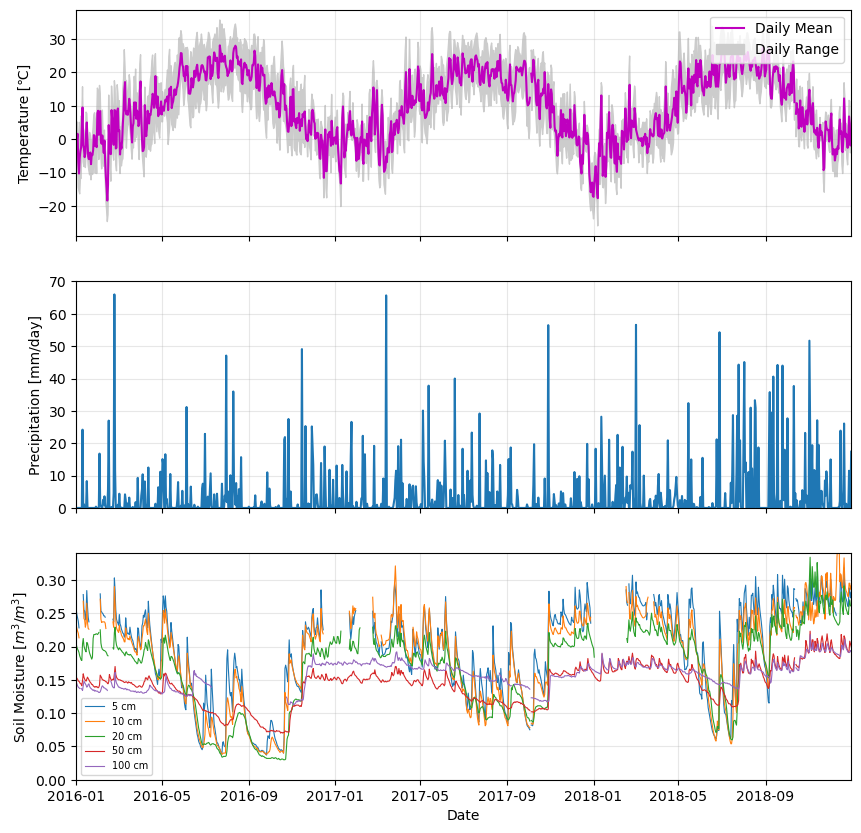

In [110]:
from matplotlib import pyplot as plt
%matplotlib inline
fig, axes = plt.subplots(nrows=3, figsize=(10, 10))
x = t_daily_min
y = t_daily_max
z = t_daily_mean

ax1, ax2, ax3 = axes

ax1.plot(date, z , color='m', label='Daily Mean')
ax1.fill_between(date, y, x, color= '0.8',label= 'Daily Range')
ax1.grid(alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_ylabel('Temperature [℃]')
ax1.set_xticklabels([])
ax1.margins(x=0)  


ax2.plot(date, p_daily_calc, color = '#1f77b4')
ax2.margins(x=0, y=0)  
ax2.set_ylim(0, 70)
ax2.set_ylabel('Precipitation [mm/day]')
ax2.set_xticklabels([])
ax2.grid(alpha=0.3)


ax3.plot(date, soil_moisture_5, color = '#1f77b4', label= '5 cm', linewidth=0.8)
ax3.plot(date, soil_moisture_10, color = '#ff7f0e', label= '10 cm', linewidth=0.8)
ax3.plot(date, soil_moisture_20, color = '#2ca02c', label= '20 cm', linewidth=0.8)
ax3.plot(date, soil_moisture_50, color = '#d62728', label= '50 cm', linewidth=0.8)
ax3.plot(date, soil_moisture_100, color = '#9467bd', label= '100 cm', linewidth=0.8)
ax3.margins(x=0, y=0)  
ax3.set_ylim(0, 0.34)
ax3.set_ylabel('Soil Moisture [$m^3$/$m^3$]')
ax3.set_xlabel('Date')

ax3.grid(alpha=0.3)
ax3.legend(loc='lower left', fontsize=7)



In [203]:
import xarray as xr
import numpy as np
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)


temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

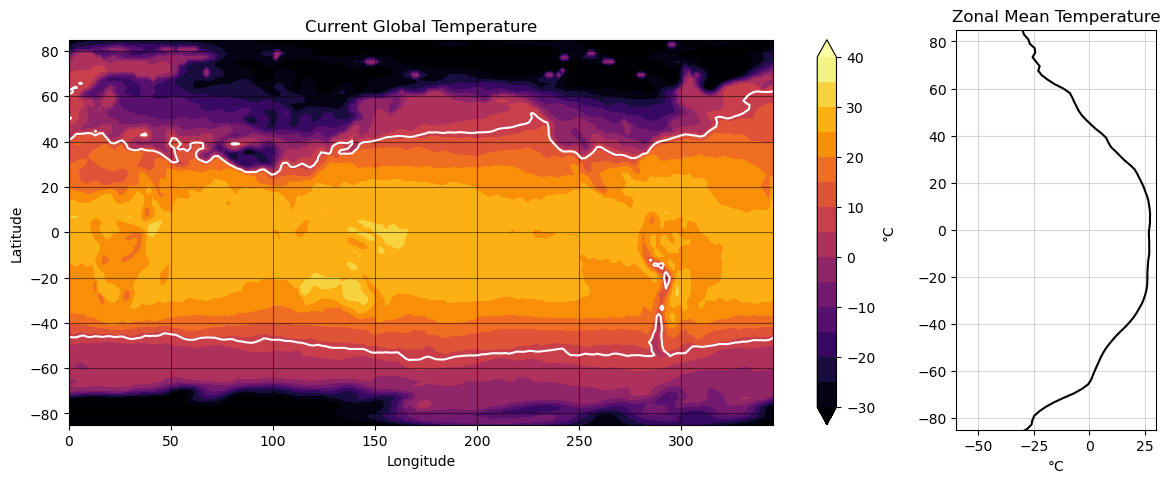

In [299]:
fig, ax = plt.subplots(figsize=(25, 5), ncols=2)

clevels=np.arange(-30, 41 ,5)
cf0 = ax[0].contourf(lon, lat, temp, clevels, cmap='inferno', extend='both')
ax[0].grid(color = 'black', alpha= 0.5)
ax[0].set_title('Current Global Temperature')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')
ax[0].set_ylim(-85, 85)
ax[0].set_xlim(0, 345)
ax[0].contour(lon, lat, temp,levels=[8], colors='white', linewidths=1.5,linestyles='solid' )

labels = fig.colorbar(cf0, ax=ax[0], label='°C')

zonal_mean = np.nanmean(temp, axis=1)
ax[1].plot(zonal_mean[:-1],lat[:-1], color='black')
ax[1].set_title('Zonal Mean Temperature')
ax[1].set_xlabel('°C')

ax[1].grid(alpha=0.5)
ax[1].set_ylim(-85, 85)
ax[1].set_xlim(-60, 30)
ax[1].set_position([0.48, 0.1, 0.08, 0.8])




In [284]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

Unzipping contents of '/home/ap4825/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/ap4825/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


/tmp/ipykernel_199010/3411310915.py:3: RuntimeWarning: divide by zero encountered in log10
  splot = ax.scatter(longitude, latitude, c=np.log10(depth), s=magnitude**4/100)


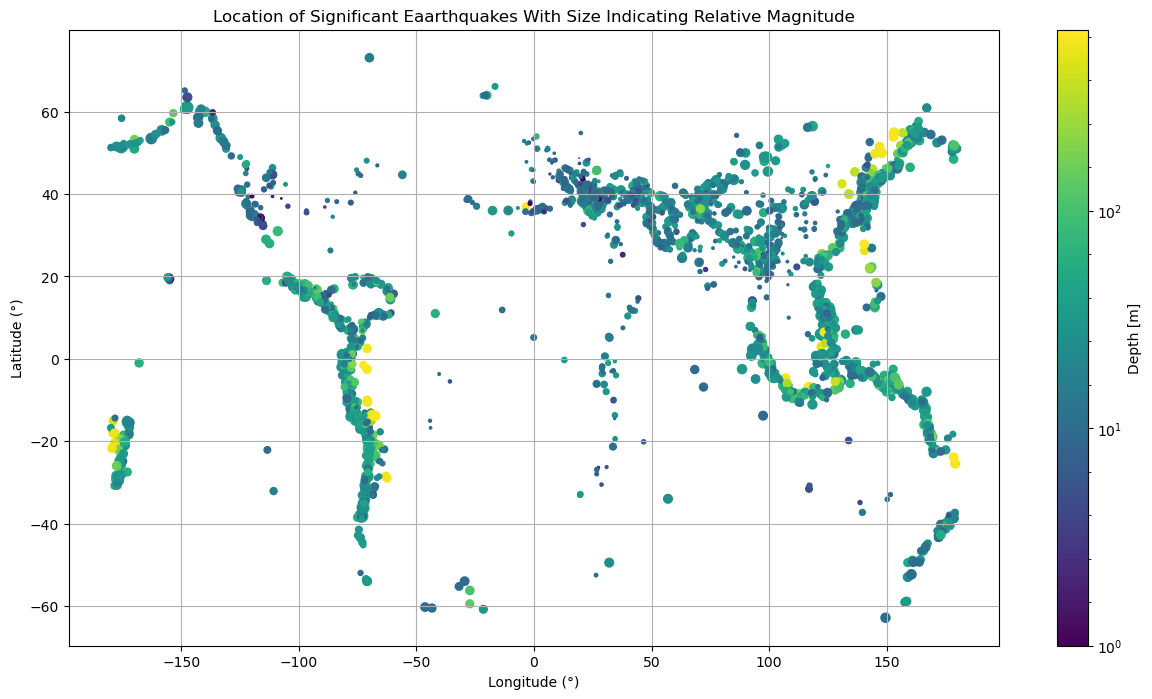

In [331]:
fig, ax = plt.subplots(figsize=(15, 8))

splot = ax.scatter(longitude, latitude, c=np.log10(depth), s=magnitude**4/100)
ax.grid()
ax.set_title('Location of Significant Eaarthquakes With Size Indicating Relative Magnitude')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
cbar =fig.colorbar(splot, ticks= [0, 1, 2], alpha=1, label='Depth [m]')

cbar.set_ticklabels(['$10^0$', '$10^1$', '$10^2$'])
cbar.minorticks_on()